### Cell 1: 使用 LLM 动态生成与提取数据 (阶段一)

In [10]:
# ==========================================
# Cell 1: LLM 动态特征生成与打分 (建议先用少量样本测试)
# ==========================================
import json
import time
import os
import pandas as pd
import random
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI
from tqdm import tqdm

# 配置大模型 API (请替换为您自己的 API Key 和 Base URL)
API_KEY = "70DR6FC7UMPN3896DKWAJKNEIKMCTCJRYJ7ZQX1X"
BASE_URL = "https://ai.gitee.com/v1"
client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
MAX_WORKERS = 10

file_lock = threading.Lock() # 防止多个线程同时写文件导致混乱

def generate_apple_review(target_quality):
    """
    target_quality: 'poor' (0-3分), 'average' (4-6分), 'excellent' (7-10分)
    """
    quality_instructions = {
        'poor': "这是一个糟糕的苹果。评论必须充满抱怨，分值必须在 0 到 4 之间。核心因子（如甜度、脆度）大部分应为 -1。",
        'average': "这是一个平庸的苹果。评论应中肯，有优有劣，分值在 5 到 7 之间。核心因子应有正有负。",
        'excellent': "这是一个完美的苹果。评论应充满赞美，分值在 8 到 10 之间。核心因子大部分应为 1。"
    }

    prompt = f"""
    你是一个苹果试吃员和数据标注专家。
    背景要求：{quality_instructions[target_quality]}
    请完成以下任务：
    1. 【写评论】：写一段关于购买和试吃苹果的评论（100字左右）。可以自由发挥场景。
    2. 【打分】：基于这段评论，给这个苹果打一个综合分数（0到10之间的整数）。
    3. 【动态提取维度】：从评论中提取关键因子，作为 JSON 的键值对。
       - 强制要求包含的基础维度（如果提到就打分，没提到打0）：'Sweetness', 'Crispness', 'Size', 'Nutrition'。
       - 自由发散维度：你可以自己从评论里提取混杂项（如 'Location', 'Month', 'Price', 'Packaging', 'Mood' 等），最多发散 6 个。
       - 打分规则：统一量化为 -1（负面/小/差）、0（中性/未提及）、1（正面/大/好/高）。

    请严格仅输出 JSON 格式，不要有任何 Markdown 标记：
    {{
      "review": "苹果个头很大，但在地摊买的，有点发面，心情很差...",
      "score": 3,
      "factors": {{
          "Sweetness": 0, "Crispness": -1, "Size": 1, "Nutrition": 0, 
          "Location": -1, "Mood": -1
      }}
    }}
    """
    try:
        response = client.chat.completions.create(
            model="Qwen3-32B", 
            messages=[{"role": "user", "content": prompt}],
            temperature=0.9 
        )
        content = response.choices[0].message.content.strip()
        if content.startswith("```json"): 
            content = content[7:-3]
        return json.loads(content)
    except Exception as e:
        print(f"API调用失败: {e}")
        return None

OUTPUT_FILE = "LLM_Dynamic_Apple_Dataset_2000.jsonl"
NUM_SAMPLES = 2000 # 初始测试建议设为 10

print(f"开始生成 {NUM_SAMPLES} 条数据...")
dataset = []

if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
        dataset = [json.loads(line) for line in f]
    print(f"已恢复之前生成的 {len(dataset)} 条数据。")

start_idx = len(dataset)
with open(OUTPUT_FILE, 'a', encoding='utf-8') as f:
    for i in tqdm(range(start_idx, NUM_SAMPLES)):
        # 核心逻辑：强制三色分布，保证 33% 是差评，33% 是中评，34% 是好评
        choice = random.random()
        if choice < 0.33:
            quality = 'poor'
        elif choice < 0.66:
            quality = 'average'
        else:
            quality = 'excellent'
            
        data = generate_apple_review(quality)
        if data:
            # 确保生成的 score 符合逻辑，如果不符合则强制修正
            f.write(json.dumps(data, ensure_ascii=False) + "\n")
            dataset.append(data)
        
        # 适当增加延时避免被封 API
        time.sleep(0.3)

print(f"数据生成完毕！共 {len(dataset)} 条。")

开始生成 2000 条数据...
已恢复之前生成的 2000 条数据。


0it [00:00, ?it/s]

数据生成完毕！共 2000 条。


### Cell 2: 动态维度对齐与预处理

In [11]:
# ==========================================
# Cell 2: 数据清洗与动态维度截断
# ==========================================
import numpy as np
import pandas as pd

df_raw = pd.read_json("LLM_Dynamic_Apple_Dataset_2000.jsonl", lines=True)
df_factors = pd.json_normalize(df_raw['factors']).fillna(0)

# 统计特征频次并截断长尾特征
feature_frequencies = (df_factors != 0).sum().sort_values(ascending=False)
print("发现的所有特征及出现次数 (前20名):")
print(feature_frequencies.head(20))

TOP_N_DIMENSIONS = 12
selected_features = feature_frequencies.head(TOP_N_DIMENSIONS).index.tolist()

# 强制保留核心因果变量
core_features = ['Sweetness', 'Crispness', 'Size']
for cf in core_features:
    if cf not in selected_features:
        selected_features.append(cf)

print(f"\n最终选定的 {len(selected_features)} 个特征维度为: \n{selected_features}")

# 构造特征矩阵 X 和标签 Y
X_matrix = df_factors[selected_features].values.astype(np.float32)
Y_scores = df_raw['score'].values.astype(np.float32)
Y_matrix = Y_scores.reshape(-1, 1)

print(f"\n特征矩阵 X 形状: {X_matrix.shape}")
print(f"标签矩阵 Y 形状: {Y_matrix.shape}")

发现的所有特征及出现次数 (前20名):
Crispness      1912
Price          1697
Packaging      1557
Sweetness      1520
Location       1511
Size           1413
Mood           1327
Month           921
Nutrition       836
Freshness       224
Appearance      191
Texture         147
Season          109
Occasion        103
Source           74
Taste            56
Juiciness        47
Seasonality      38
Quality          33
Family           32
dtype: int64

最终选定的 12 个特征维度为: 
['Crispness', 'Price', 'Packaging', 'Sweetness', 'Location', 'Size', 'Mood', 'Month', 'Nutrition', 'Freshness', 'Appearance', 'Texture']

特征矩阵 X 形状: (2000, 12)
标签矩阵 Y 形状: (2000, 1)


### Cell 3: 训练 Neural SEM (阶段二)

开始训练神经网络...
Epoch [10/60], Training Loss: 0.2043
Epoch [20/60], Training Loss: 0.1859
Epoch [30/60], Training Loss: 0.1549
Epoch [40/60], Training Loss: 0.1709
Epoch [50/60], Training Loss: 0.1470
Epoch [60/60], Training Loss: 0.1370


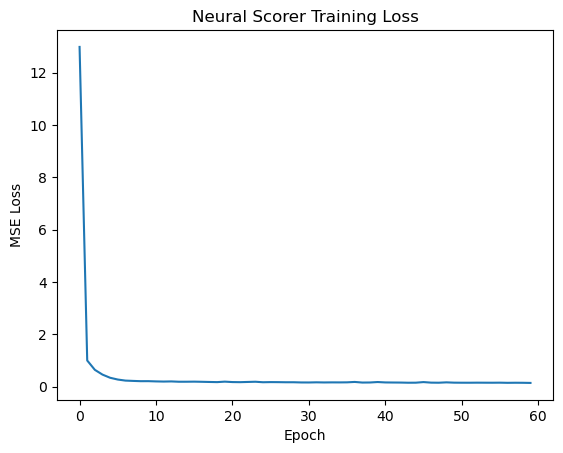

In [12]:
# ==========================================
# Cell 3: 训练神经网络以蒸馏 LLM 的非线性打分流形
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

torch.manual_seed(42)

X_tensor = torch.tensor(X_matrix)
Y_tensor = torch.tensor(Y_matrix)

# 划分训练集和测试集
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class LLMDistilledScorer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.2), 
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

input_dim = len(selected_features)
nn_model = LLMDistilledScorer(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.005)

epochs = 60
loss_history = []
print("开始训练神经网络...")

for epoch in range(epochs):
    nn_model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    loss_history.append(epoch_loss / len(train_loader))
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {loss_history[-1]:.4f}")

plt.plot(loss_history)
plt.title("Neural Scorer Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

### Cell 4: 在测试集上进行 FCI 因果发现 (阶段三)

神经网络预测得分示例 (前10个): [5.99 5.99 1.78 9.23 9.23 9.15 1.93 9.15 9.24 9.15]

正在运行 FCI 算法探测因果图 (数据维度 (400, 13))...


  0%|          | 0/13 [00:00<?, ?it/s]

X1 --> X3
X5 --> X2
X7 --> X3
X7 --> X4
X13 --> X4
X7 --> X6
X7 --> X8
X7 --> X13


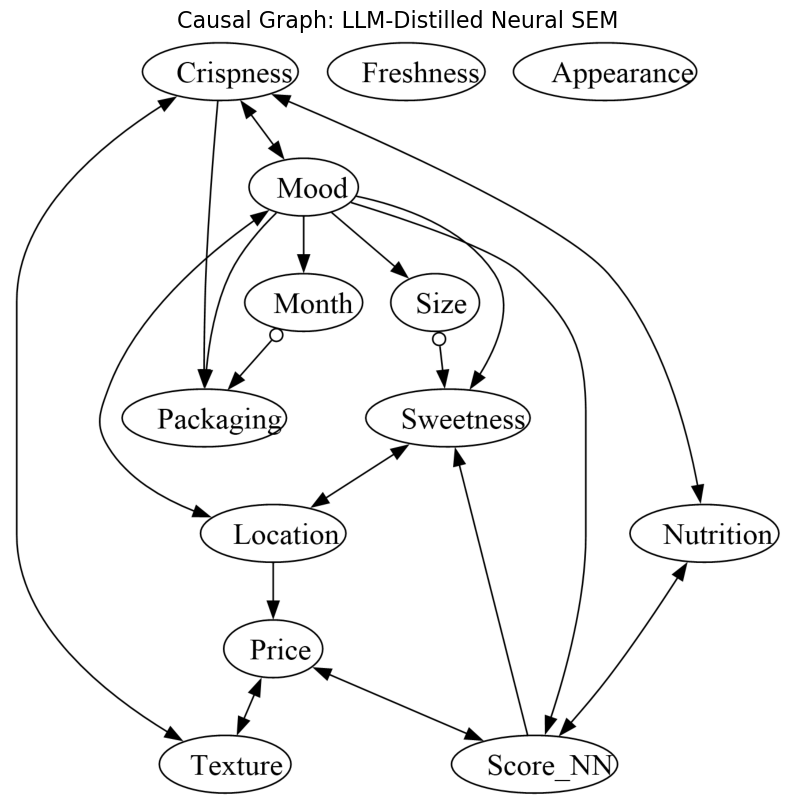


=== 因果图已成功生成！===


In [13]:
# ==========================================
# Cell 4: 测试集推理与 FCI 剔除混杂因子 (最终画图修复版)
# ==========================================
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import torch

# 1. 提取测试集的 X 矩阵
test_x_list = [x.numpy() for x, y in test_dataset]
Z_test = np.array(test_x_list)

# 2. 用训练好的神经网络打分并离散化
nn_model.eval()
with torch.no_grad():
    Y_pred = nn_model(torch.tensor(Z_test)).numpy().squeeze()

print("神经网络预测得分示例 (前10个):", np.round(Y_pred[:10], 2))
Y_discrete = pd.qcut(Y_pred, q=3, labels=[-1, 0, 1], duplicates='drop').to_numpy(dtype=np.float32)

# 3. 拼装数据传入 FCI
data_for_fci = np.column_stack((Z_test, Y_discrete))
labels = selected_features + ['Score_NN']

print(f"\n正在运行 FCI 算法探测因果图 (数据维度 {data_for_fci.shape})...")

# 4. 运行 FCI 算法，解包拿到 graph 对象
cg_neural, edges = fci(data_for_fci, indep_test='kci', alpha=0.05, verbose=False)

# 5. 可视化与保存
# 【核心修复】：不要用 for 循环去修改内部 node，直接把 labels 传给画图函数！
pydot_neural = GraphUtils.to_pydot(cg_neural, labels=labels)
pydot_neural.write_png('CausalGraph_LLM_Distilled_2000.png')

# 6. 在 Jupyter 中展示图片
plt.figure(figsize=(10, 10))
img = mpimg.imread('CausalGraph_LLM_Distilled_2000.png')
plt.imshow(img)
plt.axis('off')
plt.title("Causal Graph: LLM-Distilled Neural SEM", fontsize=16)
plt.show()

print("\n=== 因果图已成功生成！===")
